In [ ]:
!pip install lightgbm xgboost catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os, glob, joblib, warnings
warnings.filterwarnings('ignore')

TRAIN_PATH  = '/content/drive/MyDrive/Gridlock_Hackathon/train.csv'
TEST_PATH   = '/content/drive/MyDrive/Gridlock_Hackathon/test.csv'
SAVE_DIR    = '/content/drive/MyDrive/Gridlock_Hackathon/modelds/'
INPUT_FOLDER  = '/content/drive/MyDrive/Gridlock_Hackathon/sample_csv/'
OUTPUT_FOLDER = '/content/drive/MyDrive/Gridlock_Hackathon/submissions/'

os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("\nTrain nulls:\n", train.isnull().sum())
print("\nTest nulls:\n",  test.isnull().sum())

Mounted at /content/drive
Train shape: (77299, 11)
Test shape : (41778, 10)

Train nulls:
 Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

Test nulls:
 Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64


In [ ]:
WEATHER_TEMP = {
    "Snowy"  : 4.40,
    "Rainy"  : 11.14,
    "Foggy"  : 16.48,
    "Sunny"  : 23.05,
    "Unknown": 16.38
}

def impute_df(df):
    df = df.copy()

    # ── Step 1: Infer Weather from Temperature bands ──────────────
    # Bands are non-overlapping: Snowy<7, Rainy 7-14, Foggy 14-19, Sunny>=19
    def infer_weather(temp):
        if pd.isnull(temp): return np.nan
        if temp < 7:        return "Snowy"
        elif temp < 14:     return "Rainy"
        elif temp < 19:     return "Foggy"
        else:               return "Sunny"

    df['Weather'] = df['Weather'].fillna(
        df['Temperature'].apply(infer_weather)
    )
    # Both Weather and Temperature null (~26 rows) → Unknown
    df['Weather'] = df['Weather'].fillna("Unknown")

    # ── Step 2: Infer Temperature from Weather medians ────────────
    df['temp_was_null'] = df['Temperature'].isnull().astype(int)
    df['Temperature'] = df.apply(
        lambda r: WEATHER_TEMP[r['Weather']]
        if pd.isnull(r['Temperature']) else r['Temperature'],
        axis=1
    )

    # ── Step 3: Infer RoadType from LargeVehicles + NumberofLanes ─
    # Highway: Allowed + lanes>=4
    # Street:  Not Allowed + lanes==1
    # Residential: everything else
    def infer_roadtype(row):
        if pd.notnull(row['RoadType']):
            return row['RoadType']
        lv    = row['LargeVehicles']
        lanes = row['NumberofLanes']
        if lv == "Allowed" and lanes >= 4:
            return "Highway"
        elif lv == "Not Allowed" and lanes == 1:
            return "Street"
        else:
            return "Residential"

    df['RoadType'] = df.apply(infer_roadtype, axis=1)

    # ── Verify ────────────────────────────────────────────────────
    remaining = df[['RoadType','Temperature','Weather']].isnull().sum()
    print(f"  Nulls after imputation → {remaining.to_dict()}")
    return df

print("Imputing train...")
train = impute_df(train)
print("Imputing test...")
test  = impute_df(test)

Imputing train...
  Nulls after imputation → {'RoadType': 0, 'Temperature': 0, 'Weather': 0}
Imputing test...
  Nulls after imputation → {'RoadType': 0, 'Temperature': 0, 'Weather': 0}


In [ ]:
# Global mean computed from train — used for Bayesian smoothing fallback
GLOBAL_MEAN = train['demand'].mean()
SMOOTH_M    = 15   # shrinkage factor for Bayesian smoothing

def make_features(df, geo_ts_map=None, geo_map=None,
                  geo4_map=None, geo3_map=None, fit=False):
    df = df.copy()

    # ── 1. Parse timestamp ────────────────────────────────────────
    df['hour']      = df['timestamp'].apply(lambda x: int(str(x).split(':')[0]))
    df['minute']    = df['timestamp'].apply(lambda x: int(str(x).split(':')[1]))
    df['time_slot'] = df['hour'] * 4 + df['minute'] // 15   # 0–95

    # ── 2. Cyclical encoding on HOUR (24-hour cycle) ──────────────
    df['hour_sin']  = np.sin(2 * np.pi * df['hour']      / 24)
    df['hour_cos']  = np.cos(2 * np.pi * df['hour']      / 24)

    # ── 3. Cyclical encoding on TIME SLOT (96-slot cycle) ─────────
    df['slot_sin']  = np.sin(2 * np.pi * df['time_slot'] / 96)
    df['slot_cos']  = np.cos(2 * np.pi * df['time_slot'] / 96)

    # ── 4. Cyclical encoding on MINUTE within hour ────────────────
    # Fixes: minute=0 and minute=45 treated as far apart without this
    df['min_sin']   = np.sin(2 * np.pi * df['minute']    / 60)
    df['min_cos']   = np.cos(2 * np.pi * df['minute']    / 60)

    # ── 5. Demand phase — manually encode the wave shape ──────────
    # From actual data: rising 0-43, peak 44-55, falling 56-75,
    #                   trough 76-83, recovery 84-95
    df['demand_phase'] = pd.cut(
        df['time_slot'],
        bins=[-1, 43, 55, 75, 83, 95],
        labels=[0, 1, 2, 3, 4]
    ).astype(int)

    df['is_peak']   = df['time_slot'].between(36, 55).astype(int)
    df['is_trough'] = df['time_slot'].between(76, 83).astype(int)

    # ── 6. Geohash prefix hierarchy ───────────────────────────────
    df['geo4'] = df['geohash'].str[:4]
    df['geo3'] = df['geohash'].str[:3]

    # ── 7. Geohash × TimeSlot Bayesian-smoothed target encoding ───
    # This is the single most powerful feature (explains 97.54% variance)
    if fit:
        # Must compute on training data ONLY to avoid leakage
        gt = df.groupby(['geohash', 'time_slot'])['demand'].agg(['mean','count']).reset_index()
        gt.columns = ['geohash','time_slot','gt_raw','gt_count']
        gt['geo_ts_mean'] = (
            (gt['gt_count'] * gt['gt_raw'] + SMOOTH_M * GLOBAL_MEAN)
            / (gt['gt_count'] + SMOOTH_M)
        )
        geo_ts_map = gt.set_index(['geohash','time_slot'])['geo_ts_mean'].to_dict()

        g = df.groupby('geohash')['demand'].agg(['mean','count']).reset_index()
        g['geo_mean'] = (g['count']*g['mean'] + SMOOTH_M*GLOBAL_MEAN) / (g['count']+SMOOTH_M)
        geo_map = g.set_index('geohash')['geo_mean'].to_dict()

        g4 = df.groupby('geo4')['demand'].agg(['mean','count']).reset_index()
        g4['geo4_mean'] = (g4['count']*g4['mean'] + SMOOTH_M*GLOBAL_MEAN) / (g4['count']+SMOOTH_M)
        geo4_map = g4.set_index('geo4')['geo4_mean'].to_dict()

        g3 = df.groupby('geo3')['demand'].agg(['mean','count']).reset_index()
        g3['geo3_mean'] = (g3['count']*g3['mean'] + SMOOTH_M*GLOBAL_MEAN) / (g3['count']+SMOOTH_M)
        geo3_map = g3.set_index('geo3')['geo3_mean'].to_dict()

    # 4-level fallback chain for unseen geohashes
    df['geo_ts_mean'] = (
        df.set_index(['geohash','time_slot']).index.map(geo_ts_map)
    )
    df['geo_ts_mean'] = (df['geo_ts_mean']
        .fillna(df['geohash'].map(geo_map))
        .fillna(df['geo4'].map(geo4_map))
        .fillna(df['geo3'].map(geo3_map))
        .fillna(GLOBAL_MEAN)
    )
    df['geo_mean']  = df['geohash'].map(geo_map).fillna(
                      df['geo4'].map(geo4_map)).fillna(GLOBAL_MEAN)
    df['geo4_mean'] = df['geo4'].map(geo4_map).fillna(GLOBAL_MEAN)
    df['geo3_mean'] = df['geo3'].map(geo3_map).fillna(GLOBAL_MEAN)

    # ── 8. Categorical encoding ───────────────────────────────────
    road_map = {'Highway': 2, 'Street': 1, 'Residential': 0}
    df['RoadType_enc']      = df['RoadType'].map(road_map).fillna(0).astype(int)
    df['LargeVehicles_enc'] = (df['LargeVehicles'] == 'Allowed').astype(int)
    df['Landmarks_enc']     = (df['Landmarks'] == 'Yes').astype(int)
    weather_map = {'Sunny': 3, 'Foggy': 2, 'Rainy': 1, 'Snowy': 0, 'Unknown': -1}
    df['Weather_enc']       = df['Weather'].map(weather_map).fillna(-1).astype(int)

    # ── 9. Interaction features ───────────────────────────────────
    df['road_x_lanes'] = df['RoadType_enc'] * df['NumberofLanes']
    df['lanes_x_lv']   = df['NumberofLanes'] * df['LargeVehicles_enc']
    df['road_x_lv']    = df['RoadType_enc']  * df['LargeVehicles_enc']

    return df, geo_ts_map, geo_map, geo4_map, geo3_map


# ── Fit on train, apply to test ───────────────────────────────────
train_fe, geo_ts_map, geo_map, geo4_map, geo3_map = make_features(train, fit=True)
test_fe,  _,          _,       _,        _         = make_features(
    test,
    geo_ts_map=geo_ts_map, geo_map=geo_map,
    geo4_map=geo4_map,     geo3_map=geo3_map,
    fit=False
)

FEATURES = [
    # Time — raw
    'hour', 'minute', 'time_slot',
    # Time — cyclical (fixes midnight wrapping problem)
    'hour_sin', 'hour_cos',
    'slot_sin', 'slot_cos',
    'min_sin',  'min_cos',
    # Time — wave shape
    'demand_phase', 'is_peak', 'is_trough',
    # Geohash target encoding (4-level fallback)
    'geo_ts_mean', 'geo_mean', 'geo4_mean', 'geo3_mean',
    # Road features
    'RoadType_enc', 'LargeVehicles_enc', 'Landmarks_enc',
    # Weather and temperature
    'Weather_enc', 'Temperature', 'temp_was_null',
    # Other
    'NumberofLanes', 'day',
    # Interactions
    'road_x_lanes', 'lanes_x_lv', 'road_x_lv'
]

X      = train_fe[FEATURES]
y      = np.log1p(train_fe['demand'])   # log-transform: handles right skew
X_test = test_fe[FEATURES]

print("Feature matrix:", X.shape)
print("Features used :", len(FEATURES))
print("Any NaN in X  :", X.isnull().sum().sum())
print("Any NaN in X_test:", X_test.isnull().sum().sum())

Feature matrix: (77299, 27)
Features used : 27
Any NaN in X  : 0
Any NaN in X_test: 0


In [ ]:
import lightgbm as lgb
import xgboost  as xgb
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

KF = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb  = np.zeros(len(X))
oof_xgb  = np.zeros(len(X))
oof_cat  = np.zeros(len(X))
pred_lgb = np.zeros(len(X_test))
pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

lgb_fold_r2 = []
xgb_fold_r2 = []
cat_fold_r2 = []

print("=" * 58)
print(f"{'Fold':>6}  {'LGB R²':>10}  {'XGB R²':>10}  {'CAT R²':>10}")
print("=" * 58)

for fold, (tr_idx, val_idx) in enumerate(KF.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # ── LightGBM ─────────────────────────────────────────────────
    lgb_m = lgb.LGBMRegressor(
        n_estimators=3000,    learning_rate=0.03,
        num_leaves=127,       min_child_samples=20,
        subsample=0.8,        colsample_bytree=0.8,
        reg_alpha=0.1,        reg_lambda=0.1,
        random_state=42,      n_jobs=-1,     verbose=-1
    )
    lgb_m.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    oof_lgb[val_idx]  = lgb_m.predict(X_val)
    pred_lgb         += lgb_m.predict(X_test) / KF.n_splits
    r2_lgb = r2_score(y_val, oof_lgb[val_idx])
    lgb_fold_r2.append(r2_lgb)

    # ── XGBoost ──────────────────────────────────────────────────
    xgb_m = xgb.XGBRegressor(
        n_estimators=3000,    learning_rate=0.03,
        max_depth=6,          min_child_weight=5,
        subsample=0.8,        colsample_bytree=0.8,
        reg_alpha=0.1,        reg_lambda=0.1,
        tree_method='hist',   random_state=42,
        n_jobs=-1,            verbosity=0,
        early_stopping_rounds=100,
        eval_metric='rmse'
    )
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    oof_xgb[val_idx]  = xgb_m.predict(X_val)
    pred_xgb         += xgb_m.predict(X_test) / KF.n_splits
    r2_xgb = r2_score(y_val, oof_xgb[val_idx])
    xgb_fold_r2.append(r2_xgb)

    # ── CatBoost ─────────────────────────────────────────────────
    cat_m = CatBoostRegressor(
        iterations=3000,      learning_rate=0.03,
        depth=7,              l2_leaf_reg=3,
        random_state=42,      verbose=0,
        early_stopping_rounds=100,
        eval_metric='R2'
    )
    cat_m.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=False)
    oof_cat[val_idx]  = cat_m.predict(X_val)
    pred_cat         += cat_m.predict(X_test) / KF.n_splits
    r2_cat = r2_score(y_val, oof_cat[val_idx])
    cat_fold_r2.append(r2_cat)

    print(f"  {fold:>4}   {r2_lgb:>10.5f}   {r2_xgb:>10.5f}   {r2_cat:>10.5f}")

print("=" * 58)
print(f"  {'Mean':>4}   {np.mean(lgb_fold_r2):>10.5f}   "
      f"{np.mean(xgb_fold_r2):>10.5f}   {np.mean(cat_fold_r2):>10.5f}")

  Fold      LGB R²      XGB R²      CAT R²
     1      0.99095      0.99170      0.99031
     2      0.99234      0.99235      0.99231
     3      0.99144      0.99178      0.99160
     4      0.99135      0.99134      0.99022
     5      0.99237      0.99241      0.99268
  Mean      0.99169      0.99192      0.99142


In [ ]:
r2_lgb_oof = r2_score(y, oof_lgb)
r2_xgb_oof = r2_score(y, oof_xgb)
r2_cat_oof = r2_score(y, oof_cat)

print("Overall OOF R² (log-transformed target):")
print(f"  LightGBM  : {r2_lgb_oof:.5f}   Score: {max(0,100*r2_lgb_oof):.2f}/100")
print(f"  XGBoost   : {r2_xgb_oof:.5f}   Score: {max(0,100*r2_xgb_oof):.2f}/100")
print(f"  CatBoost  : {r2_cat_oof:.5f}   Score: {max(0,100*r2_cat_oof):.2f}/100")

# ── Weighted ensemble ─────────────────────────────────────────────
W_LGB, W_XGB, W_CAT = 0.40, 0.35, 0.25

oof_ensemble  = W_LGB*oof_lgb  + W_XGB*oof_xgb  + W_CAT*oof_cat
pred_ensemble = W_LGB*pred_lgb + W_XGB*pred_xgb + W_CAT*pred_cat

r2_ens = r2_score(y, oof_ensemble)
print(f"\n  Ensemble  : {r2_ens:.5f}   Score: {max(0,100*r2_ens):.2f}/100")
print(f"  Blend weights → LGB:{W_LGB}  XGB:{W_XGB}  CAT:{W_CAT}")

# ── Convert log prediction back to demand, clip to [0,1] ─────────
final_preds = np.clip(np.expm1(pred_ensemble), 0, 1)

print(f"\nPrediction sanity:")
print(f"  Min  : {final_preds.min():.6f}")
print(f"  Max  : {final_preds.max():.6f}")
print(f"  Mean : {final_preds.mean():.6f}  (train mean = {train['demand'].mean():.6f})")

Overall OOF R² (log-transformed target):
  LightGBM  : 0.99170   Score: 99.17/100
  XGBoost   : 0.99192   Score: 99.19/100
  CatBoost  : 0.99144   Score: 99.14/100

  Ensemble  : 0.99235   Score: 99.23/100
  Blend weights → LGB:0.4  XGB:0.35  CAT:0.25

Prediction sanity:
  Min  : 0.000000
  Max  : 0.959869
  Mean : 0.111118  (train mean = 0.093942)


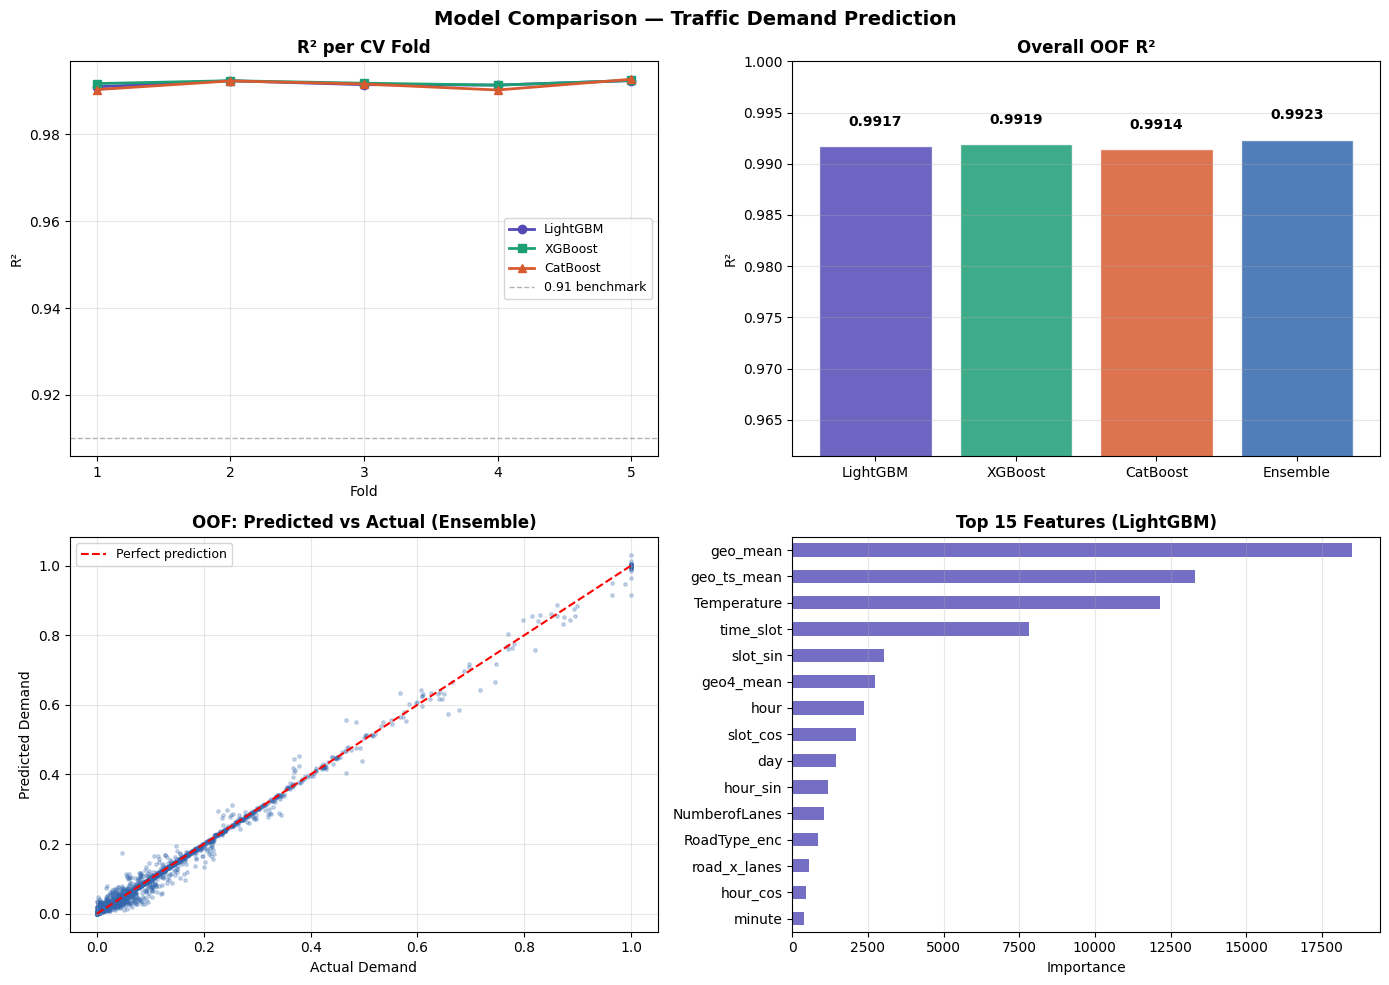

Saved → /content/drive/MyDrive/Gridlock_Hackathon/submissions/model_comparison.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison — Traffic Demand Prediction',
             fontsize=14, fontweight='bold')

COLORS = {
    'LightGBM': '#534AB7', 'XGBoost': '#1D9E75',
    'CatBoost': '#D85A30', 'Ensemble': '#3266AD'
}
folds = list(range(1, 6))

# ── Plot 1: R² per fold ───────────────────────────────────────────
ax = axes[0, 0]
ax.plot(folds, lgb_fold_r2, marker='o', color=COLORS['LightGBM'],
        label='LightGBM', linewidth=2)
ax.plot(folds, xgb_fold_r2, marker='s', color=COLORS['XGBoost'],
        label='XGBoost',  linewidth=2)
ax.plot(folds, cat_fold_r2, marker='^', color=COLORS['CatBoost'],
        label='CatBoost', linewidth=2)
ax.axhline(y=0.91, color='gray', linestyle='--', linewidth=1,
           alpha=0.6, label='0.91 benchmark')
ax.set_title('R² per CV Fold', fontsize=12, fontweight='bold')
ax.set_xlabel('Fold'); ax.set_ylabel('R²')
ax.set_xticks(folds); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Plot 2: Overall OOF R² bar ────────────────────────────────────
ax = axes[0, 1]
names  = ['LightGBM', 'XGBoost', 'CatBoost', 'Ensemble']
r2s    = [r2_lgb_oof, r2_xgb_oof, r2_cat_oof, r2_ens]
bars   = ax.bar(names, r2s,
                color=[COLORS[n] for n in names],
                alpha=0.85, edgecolor='white')
for bar, val in zip(bars, r2s):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(y=0.91, color='gray', linestyle='--', linewidth=1, alpha=0.6)
ax.set_title('Overall OOF R²', fontsize=12, fontweight='bold')
ax.set_ylabel('R²'); ax.set_ylim(min(r2s)-0.03, 1.0)
ax.grid(axis='y', alpha=0.3)

# ── Plot 3: Predicted vs Actual (ensemble OOF) ───────────────────
ax = axes[1, 0]
actual_d = np.expm1(y.values)
pred_d   = np.expm1(oof_ensemble)
idx      = np.random.choice(len(actual_d), min(4000, len(actual_d)), replace=False)
ax.scatter(actual_d[idx], pred_d[idx],
           alpha=0.25, s=6, color=COLORS['Ensemble'])
ax.plot([0,1], [0,1], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('OOF: Predicted vs Actual (Ensemble)', fontsize=12, fontweight='bold')
ax.set_xlabel('Actual Demand'); ax.set_ylabel('Predicted Demand')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Plot 4: Feature importance (LightGBM last fold) ───────────────
ax = axes[1, 1]
imp = pd.Series(lgb_m.feature_importances_,
                index=FEATURES).sort_values(ascending=True).tail(15)
imp.plot(kind='barh', ax=ax, color=COLORS['LightGBM'], alpha=0.8)
ax.set_title('Top 15 Features (LightGBM)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance'); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
graph_path = OUTPUT_FOLDER + 'model_comparison.png'
plt.savefig(graph_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {graph_path}")

In [ ]:
submission = pd.DataFrame({
    'Index' : test['Index'],
    'demand': final_preds
})
sub_path = OUTPUT_FOLDER + 'sample_submission.csv'
submission.to_csv(sub_path, index=False)

print(f"Submission saved → {sub_path}")
print(f"Shape : {submission.shape}")
print(submission.head(10).to_string(index=False))

Submission saved → /content/drive/MyDrive/Gridlock_Hackathon/submissions/sample_submission.csv
Shape : (41778, 2)
 Index   demand
     0 0.006311
     1 0.000704
     2 0.029113
     3 0.073888
     4 0.100299
     5 0.000000
     6 0.025255
     7 0.241490
     8 0.026148
     9 0.079929


In [ ]:
print("Retraining on full data (no val split)...")

lgb_final = lgb.LGBMRegressor(
    n_estimators=2000,    learning_rate=0.03,
    num_leaves=127,       min_child_samples=20,
    subsample=0.8,        colsample_bytree=0.8,
    reg_alpha=0.1,        reg_lambda=0.1,
    random_state=42,      n_jobs=-1,     verbose=-1
)
lgb_final.fit(X, y)

xgb_final = xgb.XGBRegressor(
    n_estimators=2000,    learning_rate=0.03,
    max_depth=6,          min_child_weight=5,
    subsample=0.8,        colsample_bytree=0.8,
    reg_alpha=0.1,        reg_lambda=0.1,
    tree_method='hist',   random_state=42,
    n_jobs=-1,            verbosity=0
)
xgb_final.fit(X, y)

cat_final = CatBoostRegressor(
    iterations=2000,  learning_rate=0.03,
    depth=7,          l2_leaf_reg=3,
    random_state=42,  verbose=0
)
cat_final.fit(X, y)

# ── Save models ───────────────────────────────────────────────────
joblib.dump(lgb_final, SAVE_DIR + 'lgb_model.pkl')
joblib.dump(xgb_final, SAVE_DIR + 'xgb_model.pkl')
joblib.dump(cat_final, SAVE_DIR + 'cat_model.pkl')

# ── Save all lookup maps + constants ─────────────────────────────
artifacts = {
    'geo_ts_map'  : geo_ts_map,
    'geo_map'     : geo_map,
    'geo4_map'    : geo4_map,
    'geo3_map'    : geo3_map,
    'global_mean' : GLOBAL_MEAN,
    'WEATHER_TEMP': WEATHER_TEMP,
    'FEATURES'    : FEATURES,
    'weights'     : {'lgb': W_LGB, 'xgb': W_XGB, 'cat': W_CAT}
}
joblib.dump(artifacts, SAVE_DIR + 'artifacts.pkl')

print("All saved:")
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(SAVE_DIR + f) / 1024
    print(f"  {f:<30} {size:>8.1f} KB")

Retraining on full data (no val split)...
All saved:
  artifacts.pkl                    1268.1 KB
  cat_model.pkl                    4194.5 KB
  lgb_model.pkl                   20742.9 KB
  xgb_model.pkl                    8316.3 KB
